# Data Cleaning: COE Bidding Results and Vehicle Population

This notebook profiles the two LTA datasets in `../data/` and checks them for quality problems before analysis:

1. `COEBiddingResultsPrices.csv`: the result of each COE bidding exercise, 2010–2026
2. `AnnualMotorVehiclePopulationbyVehicleType.csv`: yearly vehicle population by type, 2005–2024

For each dataset:
- check raw file's structure and text formatting
- profile the numeric columns
- check the unit, the time coverage and perform reasonableness check
- flag suspicious values

Post-review, apply the necessary data transformation, and save the cleaned data as new files in `data/` (with the suffix `_clean`). The original files are not changed.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)

DATA_DIR = '../data'
COE_PATH = f'{DATA_DIR}/COEBiddingResultsPrices.csv'
POP_PATH = f'{DATA_DIR}/AnnualMotorVehiclePopulationbyVehicleType.csv'
COE_CLEAN_PATH = f'{DATA_DIR}/COEBiddingResultsPrices_clean.csv'
POP_CLEAN_PATH = f'{DATA_DIR}/AnnualMotorVehiclePopulationbyVehicleType_clean.csv'

In [2]:
# Chart style: light background, quiet grid and axes, one blue for the data
INK, INK_2, MUTED, GRID, AXIS, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, BLUE_LIGHT = '#2a78d6', '#b7d3f6'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'axes.titlecolor': INK,
    'axes.titlesize': 10, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': GRID, 'grid.linewidth': 0.6,
    'xtick.color': AXIS, 'ytick.color': AXIS, 'xtick.labelcolor': INK_2, 'ytick.labelcolor': INK_2,
    'font.size': 9, 'figure.dpi': 110, 'figure.titlesize': 12, 'figure.titleweight': 'bold',
})
THOUSANDS = FuncFormatter(lambda x, _: f'{x:,.0f}')


def hist_panel(ax, s, title, bins=40, log=False):
    """Draw a histogram of `s` on chart panel `ax`, with a dashed line and label at the median.
    Used to see the shape of a numeric field (skew, peaks, outliers); missing values are dropped.
    Set log=True when values span several orders of magnitude, such as vehicle population."""
    s = s.dropna()
    if log:
        bins = np.logspace(np.log10(s.min()), np.log10(s.max()), bins)
        ax.set_xscale('log')
    ax.hist(s, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
    med = s.median()
    ax.axvline(med, color=INK_2, linewidth=1, linestyle='--')
    ax.annotate(f'median {med:,.0f}', xy=(med, 1), xycoords=('data', 'axes fraction'),
                xytext=(4, -2), textcoords='offset points', va='top', fontsize=8, color=INK_2)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(THOUSANDS)
    ax.set_ylabel('rows')


def box_by_group(ax, df, value, group, title):
    """Draw one box plot of column `value` for each group in column `group` on chart panel `ax`.
    Used to compare a metric across COE categories: the box is the middle 50%, the dark line
    is the median, and grey dots are outliers beyond 1.5 × the box height."""
    groups = sorted(df[group].unique())
    data = [df.loc[df[group] == g, value].dropna() for g in groups]
    ax.boxplot(data, patch_artist=True, widths=0.55,
               boxprops=dict(facecolor=BLUE_LIGHT, edgecolor=BLUE, linewidth=1),
               medianprops=dict(color=INK, linewidth=1.5),
               whiskerprops=dict(color=BLUE, linewidth=1), capprops=dict(color=BLUE, linewidth=1),
               flierprops=dict(marker='o', markersize=3, markerfacecolor=MUTED, markeredgecolor='none', alpha=0.6))
    ax.set_xticks(range(1, len(groups) + 1), [g.replace('Category ', '') for g in groups])
    ax.set_xlabel('Category')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(THOUSANDS)

---
## Part 1: COE Bidding Results

### 1.1 Raw text checks
Ingest every column as text to view formatting problems (blanks, whitespace, thousands separators).

In [59]:
# read raw coe bidding prices file as text
coe_raw = pd.read_csv(COE_PATH, dtype=str)
print(coe_raw.shape)
coe_raw.head()

(1980, 7)


,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2010-01,1,Category A,1152,1145,1342,18502
1,2010-01,1,Category B,687,679,883,19190
2,2010-01,1,Category C,173,173,265,19001
3,2010-01,1,Category D,373,365,509,889
4,2010-01,1,Category E,586,567,1011,19889


In [60]:
def text_profile(df, int_cols=()):
    """Count formatting problems in each column of a raw DataFrame read with dtype=str.
    Reports nulls, blanks, distinct values, stray spaces and commas, plus values in `int_cols`
    that are still not whole numbers after removing commas. Returns one row per column."""
    rows = []
    for col in df.columns:
        s = df[col]
        row = {
            'column': col,
            'nulls': s.isna().sum(),
            'empty': (s.str.strip() == '').sum(),
            'distinct': s.nunique(),
            'leading/trailing ws': (s != s.str.strip()).sum(),
            'has comma': s.str.contains(',', na=False).sum(),
        }
        if col in int_cols:
            row['not an integer (after removing commas)'] = (~s.str.replace(',', '').str.fullmatch(r'-?\d+').fillna(False)).sum()
        rows.append(row)
    return pd.DataFrame(rows).set_index('column')

text_profile(coe_raw, int_cols=['bidding_no', 'quota', 'bids_success', 'bids_received', 'premium'])

,nulls,empty,distinct,leading/trailing ws,has comma,not an integer (after removing commas)
column,,,,,,
month,0,0,198,0,0,NaN
bidding_no,0,0,2,0,0,0.0
vehicle_class,0,0,5,0,0,NaN
quota,0,0,862,0,0,0.0
bids_success,0,0,904,0,41,0.0
bids_received,0,0,1144,0,109,0.0
premium,0,0,1601,0,0,0.0


Summary:

- There are no missing values/nulls, empty strings or stray whitespaces. 
- There are thousands separators in `bids_success` (41 rows) and `bids_received` (109 rows). The **separators need to be removed, and the column be typed as integer after**.

### 1.2 Load with the correct types

Read the file with `thousands=','` to remove the separators and parsing `month` into a date.

In [ ]:
coe = pd.read_csv(COE_PATH, thousands=',') #removes separator commas
coe['date'] = pd.to_datetime(coe['month'])
NUM = ['quota', 'bids_success', 'bids_received', 'premium'] #identify numerical fields
coe.dtypes

month                       str
bidding_no                int64
vehicle_class               str
quota                     int64
bids_success              int64
bids_received             int64
premium                   int64
date             datetime64[us]
dtype: object

In [ ]:
# check that total count for each COE category and bidding number is as expected
coe['vehicle_class'].value_counts(), coe['bidding_no'].value_counts()

(vehicle_class
 Category A    396
 Category B    396
 Category C    396
 Category D    396
 Category E    396
 Name: count, dtype: int64,
 bidding_no
 1    990
 2    990
 Name: count, dtype: int64)

### 1.3 Unit and time coverage

The expected unit is one row per `month` × `bidding_no` × `vehicle_class`.

In [63]:
print('Duplicate grain rows:', coe.duplicated(['month', 'bidding_no', 'vehicle_class']).sum())
print('Exercises without exactly 5 categories:', (coe.groupby(['month', 'bidding_no']).size() != 5).sum())
print('Date range:', coe['month'].min(), 'to', coe['month'].max())

all_months = pd.period_range(coe['month'].min(), coe['month'].max(), freq='M').astype(str)
missing = sorted(set(all_months) - set(coe['month']))
print(f'Months in range: {len(all_months)}, months present: {coe["month"].nunique()}')
print('Missing months:', missing)

Duplicate grain rows: 0
Exercises without exactly 5 categories: 0
Date range: 2010-01 to 2026-09
Months in range: 201, months present: 198
Missing months: ['2020-04', '2020-05', '2020-06']


Summary:
- The unit is unique and every exercise covers all 5 categories. 
- **April to June 2020 are missing** because bidding was suspended during the COVID-19 "circuit breaker", so this is not lost data. Lag, rolling-average (PQP) and seasonality calculations have to allow for it.

### 1.4 Numeric profile

In [ ]:
prof = coe[NUM].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
prof['zeros'] = (coe[NUM] == 0).sum()
prof['negatives'] = (coe[NUM] < 0).sum()
prof['skew'] = coe[NUM].skew()
prof.round(1)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,zeros,negatives,skew
quota,1980.0,571.3,418.1,43.0,77.8,159.0,290.0,445.0,689.2,1435.0,2033.2,2272.0,0,0,1.6
bids_success,1980.0,562.1,416.2,39.0,74.8,151.0,281.8,433.0,678.2,1428.0,1996.8,2246.0,0,0,1.6
bids_received,1980.0,848.6,627.6,65.0,152.6,252.0,431.8,632.0,1066.2,2195.4,2966.5,4545.0,0,0,1.8
premium,1980.0,53535.0,35009.2,852.0,1502.0,2984.0,29901.8,50266.5,76304.0,118132.4,133088.6,158004.0,0,0,0.4


Summary:
- There are no missing values (total count is 1,980 records)
- There are no zeros or negative values 
- `Quota`, `bid_success`, `bids_received` are have a right-skewed distribution (ie. outliers are really high number of quota, bid_success and bids_received, long tail on the right side of the distribution)

In [65]:
coe['bid_ratio'] = coe['bids_received'] / coe['quota']   # demand ÷ supply

coe.groupby('vehicle_class').agg(
    quota_median=('quota', 'median'),
    quota_min=('quota', 'min'),
    quota_max=('quota', 'max'),
    premium_min=('premium', 'min'),
    premium_median=('premium', 'median'),
    premium_max=('premium', 'max'),
    ratio_min=('bid_ratio', 'min'),
    ratio_median=('bid_ratio', 'median'),
    ratio_max=('bid_ratio', 'max'),
).round(2)

,quota_median,quota_min,quota_max,premium_min,premium_median,premium_max,ratio_min,ratio_median,ratio_max
vehicle_class,,,,,,,,,
Category A,966.0,333,2272,18502,57049.5,133009,1.08,1.43,3.51
Category B,714.0,302,1537,19190,68844.5,150001,0.81,1.46,3.15
Category C,241.0,43,1091,19001,48901.5,95000,1.14,1.55,3.26
Category D,489.5,285,1121,852,6303.0,20090,1.08,1.28,2.52
Category E,296.0,124,750,19889,70059.5,158004,1.22,1.65,4.06


Summary:
- Based on `quota_median`, Cat A has the most supply while Cat C has the least supply. Based on the numbers the mass-market cars have about 4x (966 vs 241) the quota of goods vehicles and buses.
- Choosing Cat A over Cat B can save about $12K ($68K-$57K) in premium when looking at the median. 
- Cat D is in a very different price range. Motorcycles cost about 10% of what cars do.
- Cat E is the most expensive category (overall `premium_min`, `premium_median` and `premium_max` is higher for this category that others). has the highest maximum bid ratio, implying most competitive bidding category.

In [66]:
# Row holding the min and max of each metric
extremes = []
for col in NUM:
    for label, idx in [('min', coe[col].idxmin()), ('max', coe[col].idxmax())]:
        r = coe.loc[idx]
        extremes.append({'metric': col, 'stat': label, 'value': r[col],
                         'month': r['month'], 'bidding_no': r['bidding_no'], 'vehicle_class': r['vehicle_class']})
pd.DataFrame(extremes)

,metric,stat,value,month,bidding_no,vehicle_class
0,quota,min,43,2023-03,1,Category C
1,quota,max,2272,2016-07,2,Category A
2,bids_success,min,39,2023-03,1,Category C
3,bids_success,max,2246,2016-07,2,Category A
4,bids_received,min,65,2023-03,1,Category C
5,bids_received,max,4545,2016-06,1,Category A
6,premium,min,852,2010-02,1,Category D
7,premium,max,158004,2023-10,2,Category E


Summary:
- 2016 was peak supply with the highest quota, while 2023 was the low point. Due to the 0% car population growth in effect from Feb 2018, the quota came mainly from deregistrations of cars bought in 2006, as their 10-year COEs expired. 
- Most bids received also came at the time where quota was at its highest (high supply).

#### Distribution charts

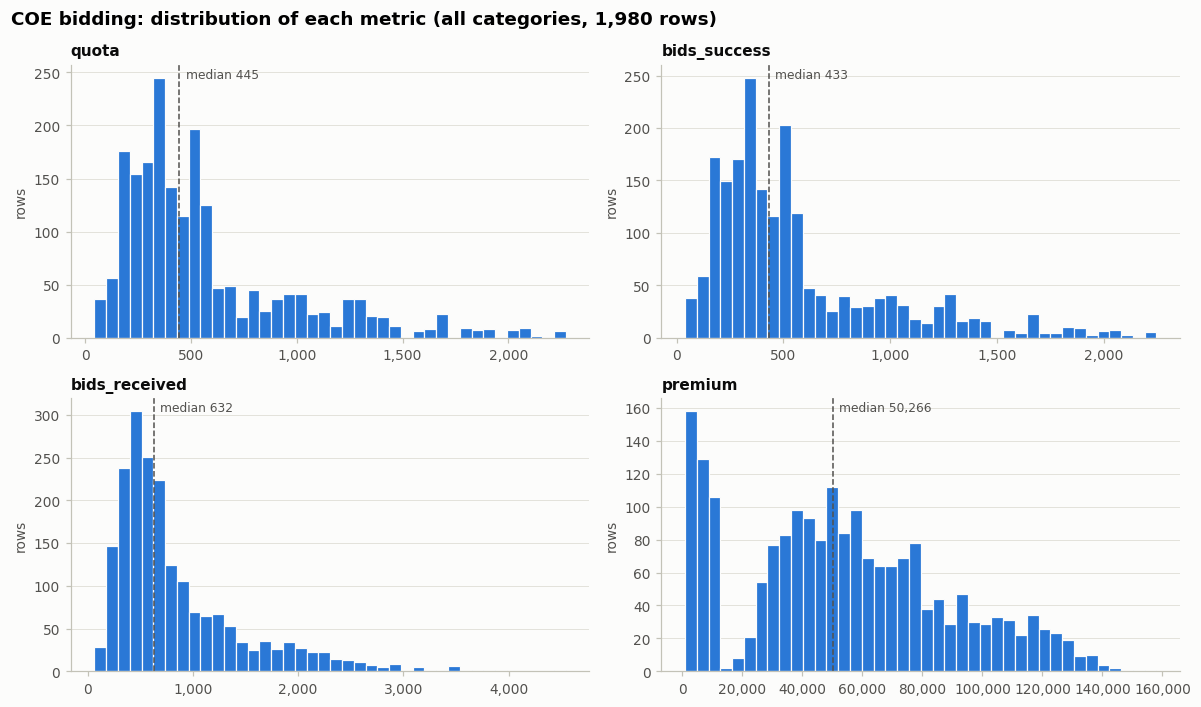

In [ ]:
# Histograms of each metric, to understand distribution, skew, outliers, etc. The median is marked with a dashed line and label.
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for ax, col in zip(axes.flat, NUM):
    hist_panel(ax, coe[col], col)
fig.suptitle(f'COE bidding: distribution of each metric (all categories, {len(coe):,} rows)', x=0.01, ha='left')
fig.tight_layout()
plt.show()

- Premium shows a bimodal distribution with a premium spike <$15K coming from Category D (Motorcycles).
- Quota, bids_success and bids_received are right-skewed when looking at all categories combined 

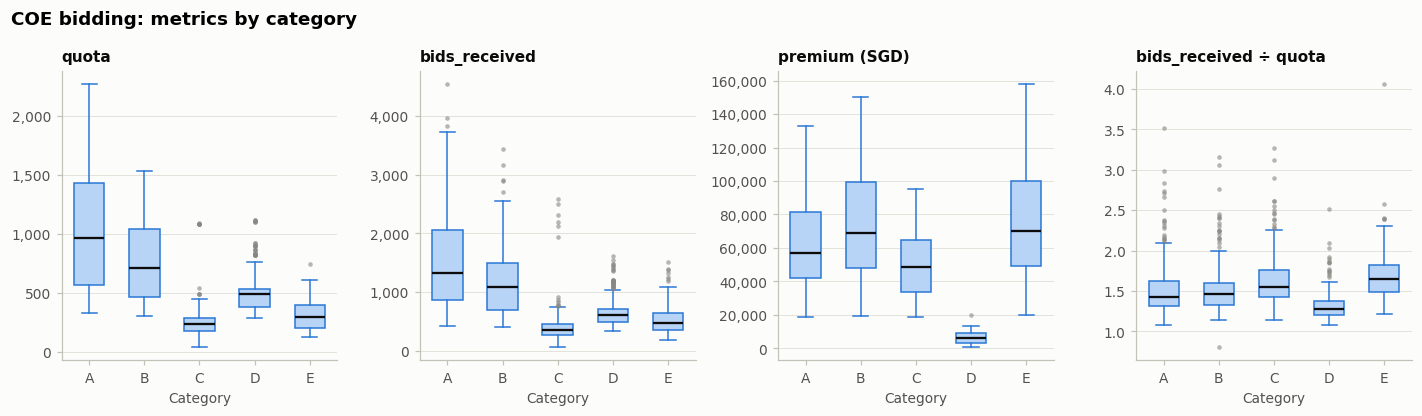

In [ ]:
# Each metric by categories, to see how the distribution differs by category. The box is the middle 50%, the dark line is the median, and grey dots are outliers beyond 1.5 × the box height.
fig, axes = plt.subplots(1, 4, figsize=(13, 3.8))
for ax, (col, title) in zip(axes, [('quota', 'quota'), ('bids_received', 'bids_received'),
                                    ('premium', 'premium (SGD)'), ('bid_ratio', 'bids_received ÷ quota')]):
    box_by_group(ax, coe, col, 'vehicle_class', title)
axes[3].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}'))
fig.suptitle('COE bidding: metrics by category', x=0.01, ha='left')
fig.tight_layout()
plt.show()

**Premium by category.** Splitting premium by category shows where its two groups come from.

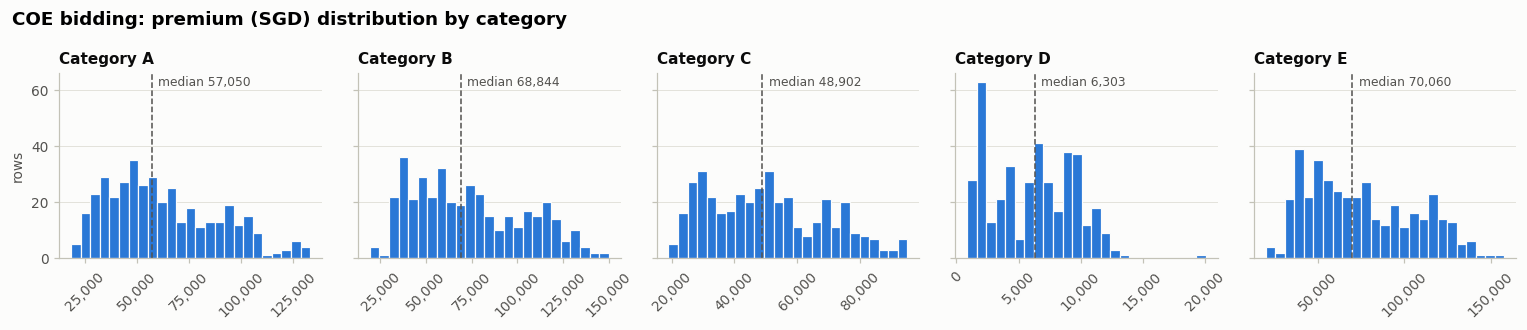

In [69]:
cats = sorted(coe['vehicle_class'].unique())
fig, axes = plt.subplots(1, 5, figsize=(14, 3), sharey=True)
for ax, cat in zip(axes, cats):
    hist_panel(ax, coe.loc[coe['vehicle_class'] == cat, 'premium'], cat, bins=25)
    ax.set_ylabel('rows' if cat == cats[0] else '')
    ax.tick_params(axis='x', labelrotation=45)
fig.suptitle('COE bidding: premium (SGD) distribution by category', x=0.01, ha='left')
fig.tight_layout()
plt.show()

**Result:**
- No zeros or negatives, and the ranges match the README.
- **Quota and bids are right-skewed.** Most exercises offer a few hundred COEs, with a long tail up to about 2,000. The tail is almost all Category A during the 2015–2019 supply peak (102 of the 110 exercises with a quota above 1,400).
- **Premium has two groups.** Category D (motorcycles) sits almost entirely below $15k. The car categories (A, B, C, E) spread widely, from about $20k to $158k, because premiums have gone through low and high periods over the 16 years. Each category's distribution is flat and wide, not a single bell shape, so an overall average hides a lot.
- **Demand relative to supply** is usually 1.3 to 1.7 bids per COE. Category E is the most competitive.
- Category D's maximum (20,090, the outlier in its box) is not a genuine value. See section 1.6.

### 1.5 Business rules
- `bids_success` should never be more than `quota` or `bids_received`.
- `bids_received` below `quota` (undersubscribed) should be very rare.

In [70]:
COLS = ['month', 'bidding_no', 'vehicle_class', 'quota', 'bids_success', 'bids_received', 'premium']

print('bids_success > quota        :', (coe['bids_success'] > coe['quota']).sum())
print('bids_success > bids_received:', (coe['bids_success'] > coe['bids_received']).sum())
print('bids_received < quota       :', (coe['bids_received'] < coe['quota']).sum())
print('bids_success < quota        :', (coe['bids_success'] < coe['quota']).sum(), f"({(coe['bids_success'] < coe['quota']).mean():.0%})")
print()
print('Unallocated COEs (quota − bids_success):')
print((coe['quota'] - coe['bids_success']).describe().round(1).to_string())

coe[coe['bids_received'] < coe['quota']][COLS]

bids_success > quota        : 0
bids_success > bids_received: 0
bids_received < quota       : 1
bids_success < quota        : 1596 (81%)

Unallocated COEs (quota − bids_success):
count    1980.0
mean        9.2
std        19.5
min         0.0
25%         1.0
50%         4.0
75%         9.0
max       464.0


,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
11,2010-02,1,Category B,1154,690,930,23180


**Result:** no row breaks the hard rules. Most exercises leave a few COEs unallocated (median 4). Only one exercise was undersubscribed: **Category B, 2010-02 exercise 1**. It is also the row with the largest unallocated gap (464). We look at it next.

### 1.6 Suspicious values
Big jumps between one exercise and the next in the same category are a quick way to find typos.

In [71]:
coe = coe.sort_values(['vehicle_class', 'month', 'bidding_no']).reset_index(drop=True)
coe['premium_pct_chg'] = coe.groupby('vehicle_class')['premium'].pct_change()

print('Exercise-to-exercise % change in premium:')
print(coe['premium_pct_chg'].describe(percentiles=[.05, .5, .95]).round(3).to_string())
coe.loc[coe['premium_pct_chg'].abs().nlargest(6).index, COLS + ['premium_pct_chg']]

Exercise-to-exercise % change in premium:
count    1975.000
mean        0.019
std         0.493
min        -0.958
5%         -0.096
50%         0.005
95%         0.125
max        21.598


,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium,premium_pct_chg
1189,2010-01,2,Category D,378,378,551,20090,21.598425
1503,2023-05,2,Category D,571,562,1438,10602,1.119552
1190,2010-02,1,Category D,371,349,525,852,-0.957591
1434,2020-07,1,Category D,869,856,1611,7702,0.715750
1502,2023-05,1,Category D,554,542,670,5002,-0.589293
1372,2017-09,1,Category D,543,535,871,5402,0.538155


In [72]:
# The first two months, all categories side by side
coe[coe['month'].isin(['2010-01', '2010-02'])].sort_values(['month', 'bidding_no', 'vehicle_class'])[COLS]

,month,bidding_no,vehicle_class,quota,bids_success,bids_received,premium
0,2010-01,1,Category A,1152,1145,1342,18502
396,2010-01,1,Category B,687,679,883,19190
792,2010-01,1,Category C,173,173,265,19001
1188,2010-01,1,Category D,373,365,509,889
1584,2010-01,1,Category E,586,567,1011,19889
1,2010-01,2,Category A,1151,1149,1673,20501
397,2010-01,2,Category B,717,717,1105,22400
793,2010-01,2,Category C,181,173,280,20090
1189,2010-01,2,Category D,378,378,551,20090
1585,2010-01,2,Category E,588,579,1322,21899


**Two values look like they were copied from the wrong row:**

| Row | Suspicious value | Copied from | Why it is wrong |
|---|---|---|---|
| 2010-01, exercise 2, **Category D** | `premium` = 20,090 | Category C premium in the same exercise (20,090) | Category D was 889 the exercise before and 852 the one after. That shows as +2,160% then −96%. |
| 2010-02, exercise 1, **Category B** | `quota` = 1,154 | Category A quota in the same exercise (1,154) | Category B's quota is about 690 in the exercises around it. The wrong value creates the only undersubscribed row and the largest unallocated gap. |

Both should be checked against LTA's published results. Until then, we set them to missing so they don't affect statistics.

### 1.7 Round-number bias
Premiums ending in `000` or `001` usually come from bidders choosing round numbers. They are expected and not a data problem.

In [73]:
print(f"premium ends in 000: {(coe['premium'] % 1000 == 0).mean():.1%}")
print(f"premium ends in 001: {(coe['premium'] % 1000 == 1).mean():.1%}")

premium ends in 000: 9.8%
premium ends in 001: 8.9%


### 1.8 Relationships between categories and columns

In [74]:
prem = coe.pivot_table(index=['month', 'bidding_no'], columns='vehicle_class', values='premium')
print(f"Category E ≥ Category B: {(prem['Category E'] >= prem['Category B']).mean():.1%} of exercises")
print(f"Category A > Category B: {(prem['Category A'] > prem['Category B']).mean():.1%} of exercises")
prem.corr().round(2)

Category E ≥ Category B: 70.7% of exercises
Category A > Category B: 5.3% of exercises


vehicle_class,Category A,Category B,Category C,Category D,Category E
vehicle_class,,,,,
Category A,1.00,0.96,0.93,0.52,0.95
Category B,0.96,1.00,0.90,0.53,1.00
Category C,0.93,0.90,1.00,0.53,0.90
Category D,0.52,0.53,0.53,1.00,0.53
Category E,0.95,1.00,0.90,0.53,1.00


In [75]:
# Pooled correlations mix the categories together and can mislead
coe[NUM + ['bid_ratio']].corr().round(2)

,quota,bids_success,bids_received,premium,bid_ratio
quota,1.00,1.00,0.96,-0.07,-0.18
bids_success,1.00,1.00,0.96,-0.06,-0.18
bids_received,0.96,0.96,1.00,-0.01,0.04
premium,-0.07,-0.06,-0.01,1.00,0.31
bid_ratio,-0.18,-0.18,0.04,0.31,1.00


In [76]:
# Within each category (Spearman)
pd.DataFrame({
    k: g[['quota', 'bid_ratio']].corrwith(g['premium'], method='spearman')
    for k, g in coe.groupby('vehicle_class')
}).T.round(2).rename(columns=lambda c: f'{c} vs premium')

,quota vs premium,bid_ratio vs premium
Category A,-0.30,0.13
Category B,-0.50,0.09
Category C,-0.37,0.07
Category D,0.29,0.05
Category E,-0.83,0.22


**Result:**
- Premiums for A, B, C and E move almost together (r ≥ 0.9). Category E tracks B very closely (r = 1.00), as the README expects.
- Category D (motorcycles) moves largely on its own (r ≈ 0.5).
- Across all rows, quota vs premium is about zero. **Within each category** it is clearly negative, strongest for E and B. Always split analysis by `vehicle_class`.

### 1.9 Yearly view and first vs second exercise

In [77]:
coe['revenue'] = coe['premium'] * coe['bids_success']
yr = coe['date'].dt.year

yearly = coe.groupby(yr).agg(quota=('quota', 'sum'), bids_success=('bids_success', 'sum'),
                             bids_received=('bids_received', 'sum'), revenue_bn=('revenue', 'sum'))
yearly['revenue_bn'] /= 1e9
for cat in ['A', 'B']:
    sub = coe[coe['vehicle_class'] == f'Category {cat}']
    yearly[f'avg_premium_{cat}'] = sub.groupby(sub['date'].dt.year)['premium'].mean()
yearly.round(2)

,quota,bids_success,bids_received,revenue_bn,avg_premium_A,avg_premium_B
date,,,,,,
2010,55388,53860,82957,1.56,30404.75,39834.12
2011,45566,44688,67215,1.96,48206.25,64937.71
2012,42942,42079,60671,2.32,63898.04,84430.58
2013,40866,39881,65501,2.11,74690.00,78711.54
2014,44585,43922,69974,2.40,67675.33,73281.54
2015,75115,74363,110189,4.15,60601.17,66851.08
2016,105103,103287,163586,4.85,49586.75,52122.17
2017,112266,110736,164849,4.88,45990.67,51800.21
2018,108772,106768,159121,3.16,33037.58,35345.21


In [78]:
q = coe.pivot_table(index=['vehicle_class', 'month'], columns='bidding_no', values='premium')
((q[2] - q[1]) / q[1]).groupby(level=0).median().rename('median % change, exercise 1 → 2').map('{:.2%}'.format)

vehicle_class
Category A    0.98%
Category B    0.65%
Category C    0.32%
Category D    0.01%
Category E    0.87%
Name: median % change, exercise 1 → 2, dtype: str

**Result:** yearly quota rose from about 41k (2013) to 112k (2017) and fell back to about 43k (2022), in line with the 10-year COE cycle. Premiums moved the opposite way. The two exercises in a month differ by less than 1% at the median in every category. Note that 2020 has only 9 months and 2026 only 9 months (to September).

---
## Part 2: Annual Motor Vehicle Population

### 2.1 Raw text checks

In [23]:
pop_raw = pd.read_csv(POP_PATH, dtype=str)
print(pop_raw.shape)
text_profile(pop_raw, int_cols=['year', 'number'])

(412, 4)


,nulls,empty,distinct,leading/trailing ws,has comma,not an integer (after removing commas)
column,,,,,,
year,0,0,20,0,0,0.0
category,0,0,6,0,0,NaN
type,0,0,22,0,0,NaN
number,0,0,395,0,0,0.0


In [24]:
pop = pd.read_csv(POP_PATH)
pop.dtypes

year        int64
category      str
type          str
number      int64
dtype: object

### 2.2 Grain and coverage
The expected grain is one row per `year` × `category` × `type`.

In [25]:
print('Duplicate grain rows:', pop.duplicated(['year', 'category', 'type']).sum())
print('Rows per year:', pop.groupby('year').size().to_dict())
pop.groupby(['category', 'type'])['year'].agg(['min', 'max', 'count'])

Duplicate grain rows: 0
Rows per year: {2005: 20, 2006: 20, 2007: 20, 2008: 20, 2009: 20, 2010: 20, 2011: 20, 2012: 20, 2013: 21, 2014: 21, 2015: 21, 2016: 21, 2017: 21, 2018: 21, 2019: 21, 2020: 21, 2021: 21, 2022: 21, 2023: 21, 2024: 21}


min   max  count
category                 type                                                  
Buses                    Excursion buses                      2005  2024     20
                         Omnibuses                            2005  2024     20
                         Private buses                        2005  2024     20
                         Private hire buses                   2005  2024     20
                         School buses (CB)                    2005  2024     20
Cars and Station-wagons  Company cars                         2005  2024     20
                         Off peak cars                        2005  2024     20
                         Private Hire (Chauffeur) cars        2013  2024     12
                         Private Hire (Self-Drive) cars       2013  2024     12
                         Private cars                         2005  2024     20
                         Rental cars                          2005  2012      8
                         Tuition cars                         2005  2024     20
Goods and Other Vehicles Goods-cum-passenger vehicles (GPVs)  2005  2024     20
                         Heavy Goods Vehicles (HGVs)          2005  2024     20
                         Light Goods Vehicles (LGVs)          2005  2024     20
                         Very Heavy Goods Vehicles (VHGVs)    2005  2024     20
Motorcycles and Scooters Motorcycles and Scooters             2005  2024     20
Tax Exempted Vehicles    Buses                                2005  2024     20
                         Cars and Station-wagons              2005  2024     20
                         Goods and Other Vehicles             2005  2024     20
                         Motorcycles and scooters             2005  2024     20
Taxis                    Taxis                                2005  2024     20

**Result:** the grain is unique. There are 20 types per year up to 2012 and 21 from 2013, because *Rental cars* (to 2012) is replaced by *Private Hire (Self-Drive)* and *Private Hire (Chauffeur)* cars (from 2013).

Also note the capitalisation: *Motorcycles and **S**cooters* (its own category) vs *Motorcycles and **s**cooters* (a type under Tax Exempted Vehicles). They are different rows, but a join on `type` alone would treat them as different values.

### 2.3 Numeric profile

In [26]:
print(pop['number'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(0).to_string())
print('skew:', round(pop['number'].skew(), 2), '| zeros:', (pop['number'] == 0).sum())
pd.concat([pop.loc[[pop['number'].idxmin()]], pop.loc[[pop['number'].idxmax()]]])

count       412.0
mean      45661.0
std      109523.0
min         274.0
1%          338.0
5%          469.0
25%        2390.0
50%        9516.0
75%       28100.0
95%      147333.0
99%      531369.0
max      540063.0
skew: 3.65 | zeros: 0


,year,category,type,number
182,2005,Tax Exempted Vehicles,Buses,274
8,2013,Cars and Station-wagons,Private cars,540063


#### Distribution charts
The values span more than three orders of magnitude, so the right-hand chart uses a log scale to show the shape of the smaller types.

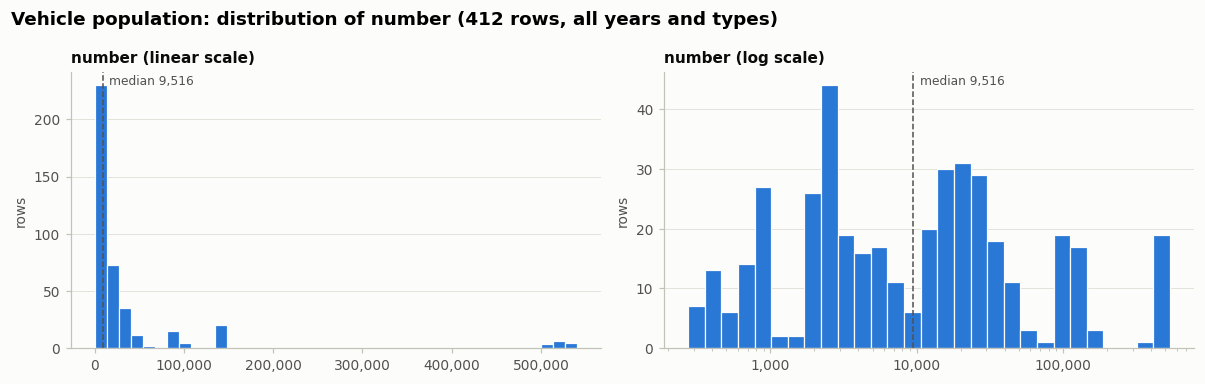

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
hist_panel(axes[0], pop['number'], 'number (linear scale)')
hist_panel(axes[1], pop['number'], 'number (log scale)', bins=30, log=True)
fig.suptitle(f'Vehicle population: distribution of number ({len(pop)} rows, all years and types)', x=0.01, ha='left')
fig.tight_layout()
plt.show()

**Where the skew comes from:** the size of each type in the latest year.

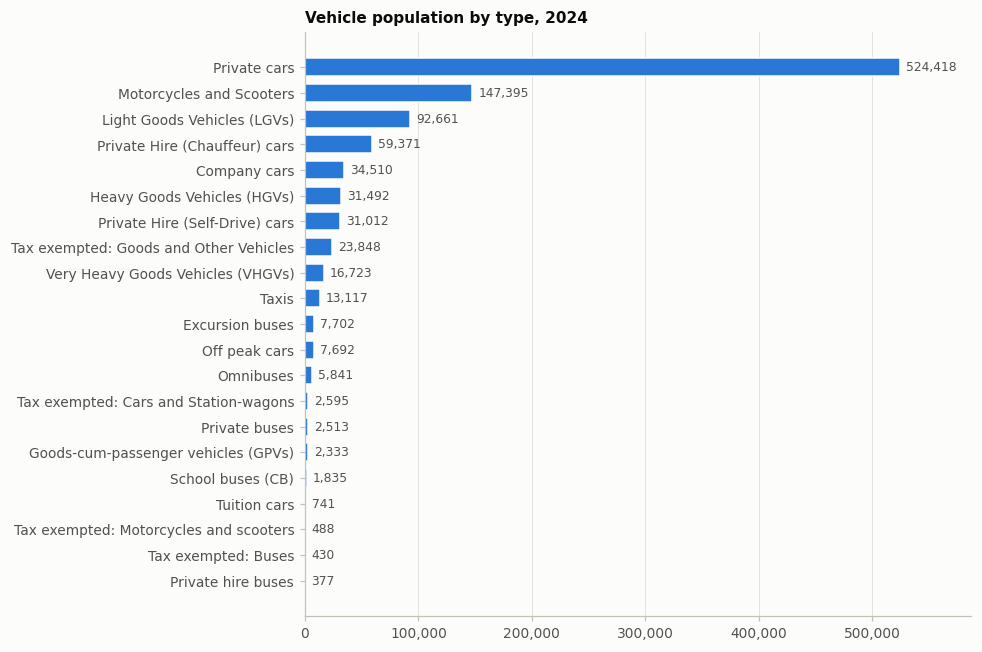

In [28]:
latest = pop['year'].max()
snap = pop[pop['year'] == latest].copy()
snap['label'] = np.where(snap['category'] == 'Tax Exempted Vehicles', 'Tax exempted: ' + snap['type'], snap['type'])
snap = snap.sort_values('number')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(snap['label'], snap['number'], color=BLUE, height=0.7, edgecolor=SURFACE, linewidth=1)
for y, v in enumerate(snap['number']):
    ax.annotate(f'{v:,}', xy=(v, y), xytext=(4, 0), textcoords='offset points', va='center', fontsize=8, color=INK_2)
ax.grid(axis='y', visible=False)
ax.grid(axis='x', visible=True)
ax.xaxis.set_major_formatter(THOUSANDS)
ax.set_xlim(0, snap['number'].max() * 1.12)
ax.set_title(f'Vehicle population by type, {latest}')
fig.tight_layout()
plt.show()

**Result:** most types have fewer than 30,000 vehicles (median about 9,500). *Private cars* alone has over 500,000, and it creates the long right tail. On a log scale the rest of the distribution is spread fairly evenly, from a few hundred up to about 150,000 (motorcycles and light goods vehicles). Use a log scale, or compare types as shares or growth rates, whenever you chart them together.

### 2.4 Totals by category

In [29]:
by_cat = pop.pivot_table(index='year', columns='category', values='number', aggfunc='sum')
by_cat['TOTAL'] = by_cat.sum(axis=1)
by_cat

category,Buses,Cars and Station-wagons,Goods and Other Vehicles,Motorcycles and Scooters,Tax Exempted Vehicles,Taxis,TOTAL
year,,,,,,,
2005,13220,438194,128193,138588,14414,22383,754992
2006,13831,472308,132841,141881,15178,23334,799373
2007,14192,514685,138604,143482,15927,24446,851336
2008,14976,550455,142966,145288,16697,24300,894682
2009,15659,576988,144802,146337,17030,24702,925518
2010,15936,595185,143613,147282,17740,26073,945829
2011,16652,603723,145158,145680,18440,27051,956704
2012,16768,617570,145046,143286,19030,28210,969910
2013,17065,621345,144202,144307,19556,27695,974170


### 2.5 Year-on-year jumps (possible reclassifications)

In [30]:
pop = pop.sort_values(['category', 'type', 'year']).reset_index(drop=True)
pop['yoy_pct'] = pop.groupby(['category', 'type'])['number'].pct_change()
pop.loc[pop['yoy_pct'].abs().nlargest(12).index]

,year,category,type,number,yoy_pct
142,2015,Cars and Station-wagons,Private Hire (Chauffeur) cars,10485,5.516470
143,2016,Cars and Station-wagons,Private Hire (Chauffeur) cars,31962,2.048355
141,2014,Cars and Station-wagons,Private Hire (Chauffeur) cars,1609,1.620521
121,2006,Cars and Station-wagons,Off peak cars,24413,0.885611
144,2017,Cars and Station-wagons,Private Hire (Chauffeur) cars,46903,0.467461
122,2007,Cars and Station-wagons,Off peak cars,33983,0.392004
387,2020,Tax Exempted Vehicles,Motorcycles and scooters,621,0.259635
131,2016,Cars and Station-wagons,Off peak cars,22562,-0.259510
115,2020,Cars and Station-wagons,Company cars,30966,0.258269
132,2017,Cars and Station-wagons,Off peak cars,16947,-0.248870


In [31]:
# Around the 2012–2013 break
by_type = pop.pivot_table(index=['category', 'type'], columns='year', values='number')
(by_type.pct_change(axis=1) * 100).loc[:, [2012, 2013, 2014]].round(1)

year                                                          2012  2013   2014
category                 type                                                  
Buses                    Excursion buses                       9.3   9.7    8.0
                         Omnibuses                             2.4   8.1    4.5
                         Private buses                        -3.5  -3.3   -2.4
                         Private hire buses                   -8.1 -13.4  -18.9
                         School buses (CB)                    -0.3   0.4   -0.1
Cars and Station-wagons  Company cars                          5.1   1.6    0.5
                         Off peak cars                        -5.7  -6.5   -9.7
                         Private Hire (Chauffeur) cars         NaN   NaN  162.1
                         Private Hire (Self-Drive) cars        NaN   NaN    9.2
                         Private cars                          2.8   0.9   -0.6
                         Rental cars                           6.8   NaN    NaN
                         Tuition cars                         -2.2  -0.2   -2.6
Goods and Other Vehicles Goods-cum-passenger vehicles (GPVs)  -5.9 -23.6   -9.4
                         Heavy Goods Vehicles (HGVs)           0.0   0.7   -1.1
                         Light Goods Vehicles (LGVs)          -0.8  -1.7    0.4
                         Very Heavy Goods Vehicles (VHGVs)     6.7  10.2    3.4
Motorcycles and Scooters Motorcycles and Scooters             -1.6   0.7    0.1
Tax Exempted Vehicles    Buses                                 0.0  12.7    0.2
                         Cars and Station-wagons              -4.5  -4.0    3.0
                         Goods and Other Vehicles              5.2   5.0    6.5
                         Motorcycles and scooters             -6.3 -23.9   -0.8
Taxis                    Taxis                                 4.3  -1.8    3.8

**Result:** the biggest jumps are real market changes: private-hire chauffeur cars growing after ride-hailing arrived, and off-peak cars shrinking. The 2013 falls in **GPVs (−23.6%)** and **tax-exempted motorcycles (−23.9%)** happen in the same year the car types were redefined. They are likely reclassifications, so treat 2012→2013 as a break in the series.

In [32]:
cars = pop[pop['category'] == 'Cars and Station-wagons'].pivot_table(index='year', columns='type', values='number')
cars

type,Company cars,Off peak cars,Private Hire (Chauffeur) cars,Private Hire (Self-Drive) cars,Private cars,Rental cars,Tuition cars
year,,,,,,,
2005,14936.0,12947.0,NaN,NaN,401638.0,7756.0,917.0
2006,15828.0,24413.0,NaN,NaN,421904.0,9235.0,928.0
2007,16954.0,33983.0,NaN,NaN,451745.0,11054.0,949.0
2008,18246.0,42208.0,NaN,NaN,476634.0,12391.0,976.0
2009,18874.0,47224.0,NaN,NaN,497116.0,12763.0,1011.0
2010,19733.0,50040.0,NaN,NaN,511125.0,13347.0,940.0
2011,20372.0,47899.0,NaN,NaN,520614.0,13919.0,919.0
2012,21403.0,45173.0,NaN,NaN,535233.0,14862.0,899.0
2013,21756.0,42233.0,614.0,15782.0,540063.0,NaN,897.0


---
## Part 3: Summary of issues

| Severity | Dataset | Issue | Action |
|---|---|---|---|
| 🔴 High | COE | 2010-01 exercise 2, Category D `premium` = 20,090 (copied from Category C) | Set to missing |
| 🔴 High | COE | 2010-02 exercise 1, Category B `quota` = 1,154 (copied from Category A) | Set to missing |
| 🟠 Medium | COE | No bidding April–June 2020 (COVID-19 suspension) | Keep in mind for lags and rolling averages |
| 🟡 Low | Population | Types redefined in 2012→2013 (rental → private hire; GPV and tax-exempted motorcycle drops) | Treat as a break in the series |
| ⚪ Info | COE | Thousands separators in `bids_success` / `bids_received` | Handled by `thousands=','` |
| ⚪ Info | Population | "Motorcycles and scooters" vs "Motorcycles and Scooters" | Don't join on `type` alone |

## Part 4: Apply fixes and save
The two suspicious values are set to missing (`pd.NA`), not replaced with a guess. The cleaned data is saved as new `_clean.csv` files in `data/`. The original files are not changed.

In [33]:
coe_clean = pd.read_csv(COE_PATH, thousands=',')
coe_clean['date'] = pd.to_datetime(coe_clean['month'])
coe_clean[NUM] = coe_clean[NUM].astype('Int64')   # nullable integers, so missing values are allowed

fixes = [
    # (month, bidding_no, vehicle_class, column)
    ('2010-01', 2, 'Category D', 'premium'),
    ('2010-02', 1, 'Category B', 'quota'),
]
for month, bid, cls, col in fixes:
    mask = (coe_clean['month'] == month) & (coe_clean['bidding_no'] == bid) & (coe_clean['vehicle_class'] == cls)
    assert mask.sum() == 1
    print(f'{month} #{bid} {cls}: {col} {coe_clean.loc[mask, col].item()} -> <NA>')
    coe_clean.loc[mask, col] = pd.NA

coe_clean[NUM].isna().sum()

2010-01 #2 Category D: premium 20090 -> <NA>
2010-02 #1 Category B: quota 1154 -> <NA>


quota            1
bids_success     0
bids_received    0
premium          1
dtype: int64

In [34]:
pop_clean = pd.read_csv(POP_PATH)   # no value changes needed

# Check: the maximum Category D premium should now look reasonable
coe_clean.groupby('vehicle_class')['premium'].max()

vehicle_class
Category A    133009
Category B    150001
Category C     95000
Category D     13189
Category E    158004
Name: premium, dtype: Int64

### Save the cleaned files
- `month` is kept as `YYYY-MM` text, the same as the original, so `date` is not saved. Parse it again after loading.
- The counts no longer have thousands separators.
- The two removed values are saved as empty cells.

In [35]:
coe_clean.drop(columns='date').to_csv(COE_CLEAN_PATH, index=False)
pop_clean.to_csv(POP_CLEAN_PATH, index=False)

# Read the files back to check them
coe_check = pd.read_csv(COE_CLEAN_PATH, dtype={c: 'Int64' for c in NUM})
pop_check = pd.read_csv(POP_CLEAN_PATH)

assert coe_check.shape == (len(coe_raw), coe_raw.shape[1])
assert pop_check.shape == pop_raw.shape
assert coe_check[NUM].isna().sum().sum() == len(fixes)
assert not coe_check.astype(str).apply(lambda s: s.str.contains(',')).any().any()

print(f'Saved {COE_CLEAN_PATH}: {coe_check.shape[0]:,} rows × {coe_check.shape[1]} columns')
print(f'Saved {POP_CLEAN_PATH}: {pop_check.shape[0]:,} rows × {pop_check.shape[1]} columns')
coe_check.dtypes

Saved ../data/COEBiddingResultsPrices_clean.csv: 1,980 rows × 7 columns
Saved ../data/AnnualMotorVehiclePopulationbyVehicleType_clean.csv: 412 rows × 4 columns


month              str
bidding_no       int64
vehicle_class      str
quota            Int64
bids_success     Int64
bids_received    Int64
premium          Int64
dtype: object

To load the cleaned COE data in another notebook:

```python
coe = pd.read_csv('../data/COEBiddingResultsPrices_clean.csv',
                  dtype={'quota': 'Int64', 'bids_success': 'Int64', 'bids_received': 'Int64', 'premium': 'Int64'})
coe['date'] = pd.to_datetime(coe['month'])
```